# Preprocessing

In [2]:
import os
import pandas as pd
import numpy as np
import librosa

# Display full DataFrame when printing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

DATASET_PATH = "Audio"

# Label mappings
emotion_map = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}
intensity_map = {"01": "normal", "02": "strong"}
statement_map = {"01": "kids", "02": "dogs"}
repetition_map = {"01": "first", "02": "second"}
modality_map = {"01": "audio_video", "02": "video_only", "03": "audio_only"}
channel_map = {"01": "speech", "02": "song"}

# Extract MFCC + engineered features from trimmed audio
def extract_features(path, top_db=40, n_mfcc=13):
    try:
        y, sr = librosa.load(path, sr=None)
        y_trimmed, _ = librosa.effects.trim(y, top_db=top_db)

        # MFCCs and deltas
        mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=n_mfcc)
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        mfcc_mean = np.mean(mfcc.T, axis=0)
        delta_mean = np.mean(delta.T, axis=0)
        delta2_mean = np.mean(delta2.T, axis=0)

        # Chroma
        chroma = librosa.feature.chroma_stft(y=y_trimmed, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)

        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y_trimmed)
        zcr_mean = np.mean(zcr)

        # RMSE
        rmse = librosa.feature.rms(y=y_trimmed)
        rmse_mean = np.mean(rmse)

        # Duration
        trimmed_duration = librosa.get_duration(y=y_trimmed, sr=sr)

        return {
            "mfcc": mfcc_mean,
            "delta": delta_mean,
            "delta2": delta2_mean,
            "chroma": chroma_mean,
            "zcr": zcr_mean,
            "rmse": rmse_mean,
            "duration": trimmed_duration
        }

    except Exception as e:
        print(f"❌ Error processing {path}: {e}")
        return None

# Main loop
data = []

for root, _, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            parts = file.split('.')[0].split('-')
            modality = modality_map.get(parts[0])
            channel = channel_map.get(parts[1])
            emotion = emotion_map.get(parts[2])
            intensity = intensity_map.get(parts[3], "unknown")
            statement = statement_map.get(parts[4])
            repetition = repetition_map.get(parts[5])
            actor = int(parts[6])
            gender = "female" if actor % 2 == 0 else "male"

            path = os.path.join(root, file)
            features = extract_features(path)

            if features:
                row = {
                    "path": path,
                    "modality": modality,
                    "channel": channel,
                    "emotion": emotion,
                    "intensity": intensity,
                    "statement": statement,
                    "repetition": repetition,
                    "actor": actor,
                    "gender": gender,
                    "trimmed_duration": features["duration"],
                    "zcr": features["zcr"],
                    "rmse": features["rmse"]
                }

                for i in range(13):
                    row[f"mfcc_{i+1}"] = features["mfcc"][i]
                    row[f"delta_{i+1}"] = features["delta"][i]
                    row[f"delta2_{i+1}"] = features["delta2"][i]

                for i in range(12):  # 12 chroma bins
                    row[f"chroma_{i+1}"] = features["chroma"][i]

                data.append(row)

# Final DataFrame
df = pd.DataFrame(data)
print(df.head())
print("\n✅ Final shape:", df.shape)


                                      path    modality channel  emotion  \
0  Audio/Actor_16/03-01-05-01-02-01-16.wav  audio_only  speech    angry   
1  Audio/Actor_16/03-01-06-01-02-02-16.wav  audio_only  speech  fearful   
2  Audio/Actor_16/03-01-06-02-01-02-16.wav  audio_only  speech  fearful   
3  Audio/Actor_16/03-01-05-02-01-01-16.wav  audio_only  speech    angry   
4  Audio/Actor_16/03-01-07-01-01-01-16.wav  audio_only  speech  disgust   

  intensity statement repetition  actor  gender  trimmed_duration       zcr  \
0    normal      dogs      first     16  female          1.941333  0.095967   
1    normal      dogs     second     16  female          1.845333  0.088351   
2    strong      kids     second     16  female          2.058667  0.092383   
3    strong      kids      first     16  female          1.962667  0.078196   
4    normal      kids      first     16  female          1.856000  0.074576   

       rmse      mfcc_1   delta_1  delta2_1      mfcc_2   delta_2  delta2_

In [3]:
df.head(10)

,path,modality,channel,emotion,intensity,statement,repetition,actor,gender,trimmed_duration,zcr,rmse,mfcc_1,delta_1,delta2_1,mfcc_2,delta_2,delta2_2,mfcc_3,delta_3,delta2_3,mfcc_4,delta_4,delta2_4,mfcc_5,delta_5,delta2_5,mfcc_6,delta_6,delta2_6,mfcc_7,delta_7,delta2_7,mfcc_8,delta_8,delta2_8,mfcc_9,delta_9,delta2_9,mfcc_10,delta_10,delta2_10,mfcc_11,delta_11,delta2_11,mfcc_12,delta_12,delta2_12,mfcc_13,delta_13,delta2_13,chroma_1,chroma_2,chroma_3,chroma_4,chroma_5,chroma_6,chroma_7,chroma_8,chroma_9,chroma_10,chroma_11,chroma_12
0,Audio/Actor_16/03-01-05-01-02-01-16.wav,audio_only,speech,angry,normal,dogs,first,16,female,1.941333,0.095967,0.023272,-415.680023,-1.586419,-0.459140,95.570572,0.063254,-0.318402,-15.122651,0.480305,0.044635,18.431467,-0.420656,0.216948,-12.911190,0.071469,0.024376,-2.582513,-0.112121,0.021822,-22.018345,0.184437,0.105489,-3.279297,0.160032,0.024132,-20.968021,0.217111,0.069828,-15.683751,0.061503,0.084022,-17.940592,-0.056449,0.013104,-2.764513,-0.088582,-0.055551,-9.164708,0.111288,0.027823,0.280660,0.219307,0.278373,0.336508,0.383528,0.449668,0.363069,0.365254,0.461737,0.423752,0.404152,0.362401
1,Audio/Actor_16/03-01-06-01-02-02-16.wav,audio_only,speech,fearful,normal,dogs,second,16,female,1.845333,0.088351,0.016691,-465.809631,-0.606517,-0.643605,96.918533,0.303549,-0.212449,-10.517126,0.055581,0.143577,14.396163,-0.390274,-0.048594,-5.490643,0.023613,0.001642,8.059615,-0.077334,-0.033768,-21.805391,0.064399,0.049581,-12.765356,-0.004348,0.116799,-22.549929,0.005212,0.153441,-16.329945,-0.046418,0.079756,-11.057807,0.089463,0.014976,-0.991880,-0.016213,-0.013711,-13.535925,-0.048184,0.061399,0.431030,0.396331,0.409398,0.348741,0.288207,0.292762,0.296504,0.283797,0.311890,0.384194,0.405548,0.425267
2,Audio/Actor_16/03-01-06-02-01-02-16.wav,audio_only,speech,fearful,strong,kids,second,16,female,2.058667,0.092383,0.068880,-321.204102,-0.635513,-0.560617,68.217575,0.143127,0.060873,-41.296333,0.042268,0.098498,-4.756531,-0.200629,-0.012833,-13.022684,0.026347,0.091979,-4.733933,0.160109,-0.041099,-31.103058,0.112956,0.039662,-11.751559,-0.031668,0.032834,-21.290955,0.041877,0.021339,-16.034061,-0.108452,0.002519,-14.231901,0.048358,0.006999,-3.737115,0.109978,-0.011394,-15.151870,-0.035771,0.037410,0.264508,0.273196,0.256347,0.189985,0.212268,0.314165,0.363233,0.449864,0.423769,0.411887,0.394375,0.353491
3,Audio/Actor_16/03-01-05-02-01-01-16.wav,audio_only,speech,angry,strong,kids,first,16,female,1.962667,0.078196,0.047095,-338.281281,-1.034112,-0.578688,94.922005,0.426836,-0.130485,-18.409515,0.537449,-0.033310,10.429181,-0.171387,-0.001429,-7.102742,0.025167,0.093177,-6.317114,0.016264,0.049063,-30.055859,0.168866,0.096473,0.205476,-0.035707,0.040025,-13.365784,0.037442,0.013806,-18.313503,-0.102719,0.046630,-13.098593,-0.028557,0.069470,1.184555,0.028767,0.019264,-10.483021,0.080541,-0.011162,0.403796,0.434363,0.348176,0.377743,0.372361,0.363391,0.279748,0.232312,0.287468,0.309986,0.285682,0.318341
4,Audio/Actor_16/03-01-07-01-01-01-16.wav,audio_only,speech,disgust,normal,kids,first,16,female,1.856000,0.074576,0.008383,-505.555817,-1.057443,-0.955755,115.411789,0.377971,-0.184705,0.196157,0.266546,0.111111,21.722277,-0.188115,0.019438,-4.467556,0.124900,0.086951,3.322850,0.164913,0.008722,-15.730408,0.157133,0.031861,0.220434,-0.006884,-0.012641,-23.460207,0.048835,0.079594,-8.447276,-0.069598,0.044869,-13.882384,0.040003,0.049042,0.194186,0.018003,-0.000330,-6.124894,0.027266,0.033928,0.431378,0.347415,0.300742,0.318941,0.344937,0.417142,0.389657,0.411644,0.355176,0.301990,0.328397,0.420735
5,Audio/Actor_16/03-01-04-01-01-02-16.wav,audio_only,speech,sad,normal,kids,second,16,female,2.240000,0.058131,0.004303,-627.115173,-0.177693,0.002141,106.155220,-0.164498,-0.007112,4.801195,-0.013568,-0.014222,13.445081,0.070831,-0.005086,3.748757,0.094986,-0.008128,2.304115,0.102125,-0.016466,-16.321444,0.098738,-0.002873,-9.229330,0.078216,0.016171,-17.129288,0.062922,0.010415,-6.842928,0.047566,-0.01232

# EDA

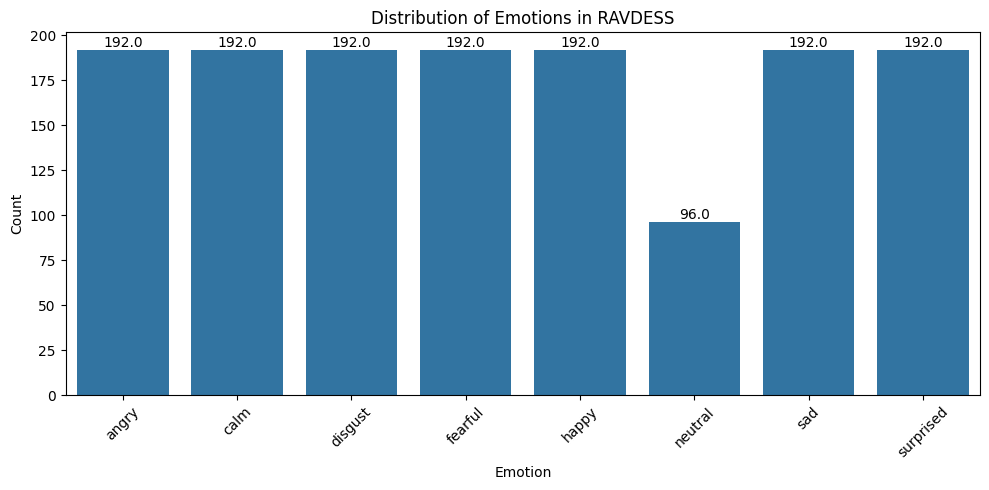

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="emotion", order=sorted(df["emotion"].unique()))
plt.title("Distribution of Emotions in RAVDESS")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Add count labels on each bar
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=10, color='black')

plt.tight_layout()
plt.show()


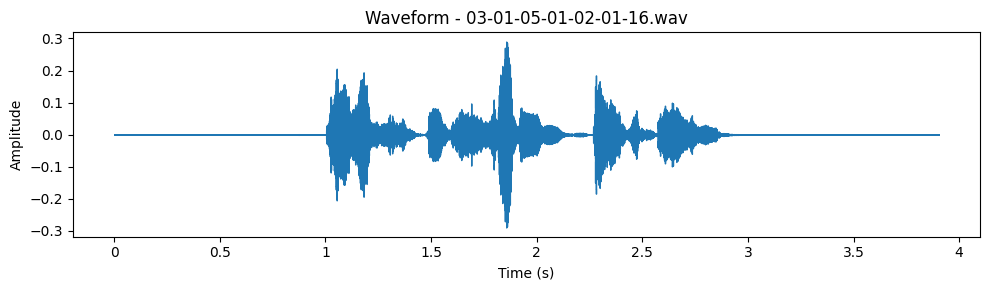

In [6]:
import librosa
import librosa.display

# Pick a sample
sample_path = df[df["emotion"] == "angry"]["path"].iloc[0]
y, sr = librosa.load(sample_path)

plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title(f"Waveform - {sample_path.split('/')[-1]}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


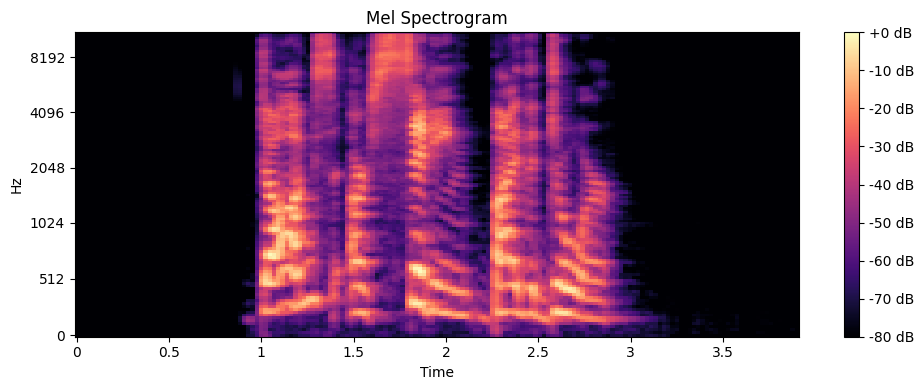

In [7]:
import numpy as np
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()

/var/folders/lc/kxf912cj7cx90vvvmr9mfwn80000gn/T/ipykernel_1376/332791180.py:2: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  df["duration"] = df["path"].apply(lambda x: librosa.get_duration(filename=x))


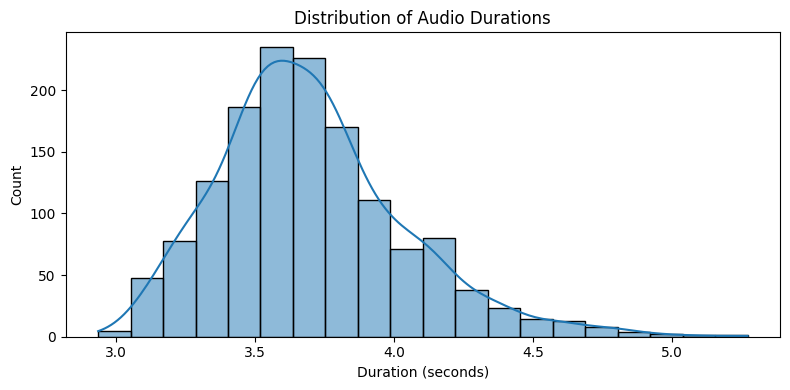

In [8]:
# Extract duration for each sample
df["duration"] = df["path"].apply(lambda x: librosa.get_duration(filename=x))

plt.figure(figsize=(8, 4))
sns.histplot(df["duration"], bins=20, kde=True)
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.tight_layout()
plt.show()

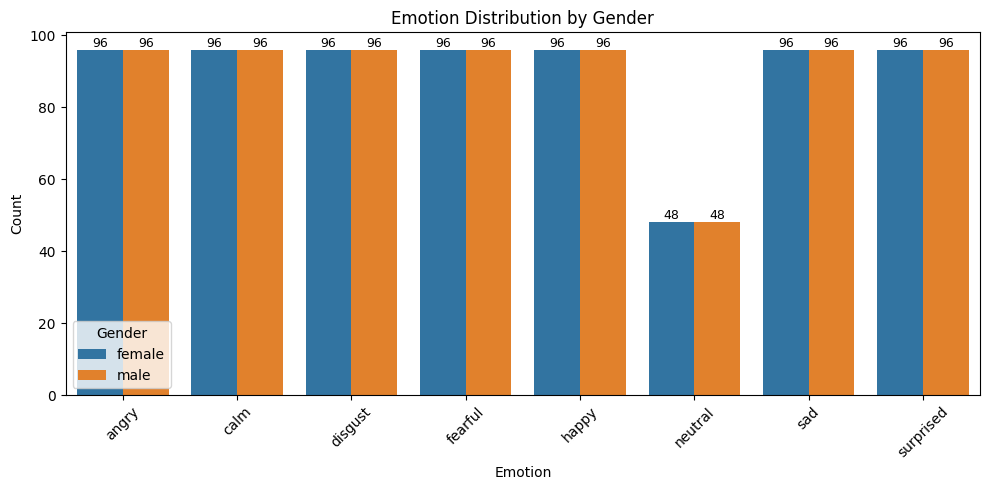

In [9]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="emotion", hue="gender", order=sorted(df["emotion"].unique()))
plt.title("Emotion Distribution by Gender")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.legend(title="Gender")
plt.xticks(rotation=45)

# Add count labels to grouped bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

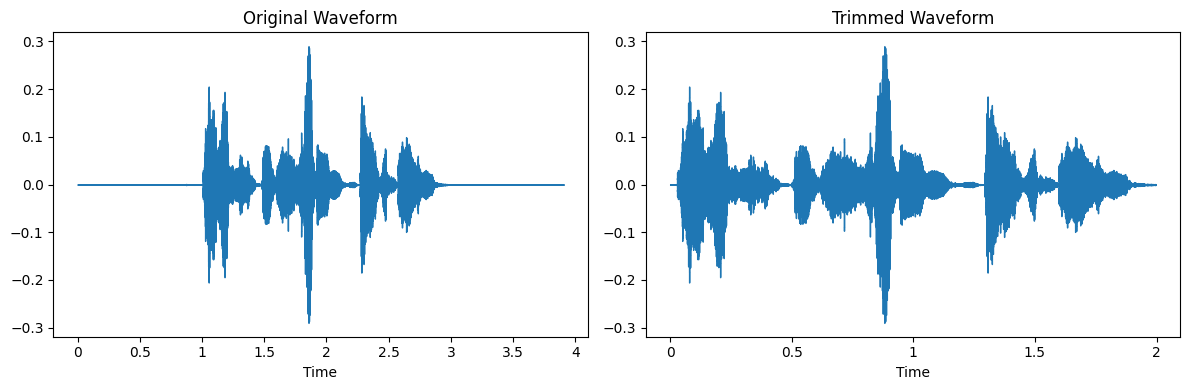

In [10]:
# Load and trim
y, sr = librosa.load(sample_path)
y_trimmed, _ = librosa.effects.trim(y, top_db=40)

# Plot both
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
librosa.display.waveshow(y, sr=sr)
plt.title("Original Waveform")

plt.subplot(1, 2, 2)
librosa.display.waveshow(y_trimmed, sr=sr)
plt.title("Trimmed Waveform")

plt.tight_layout()
plt.show()


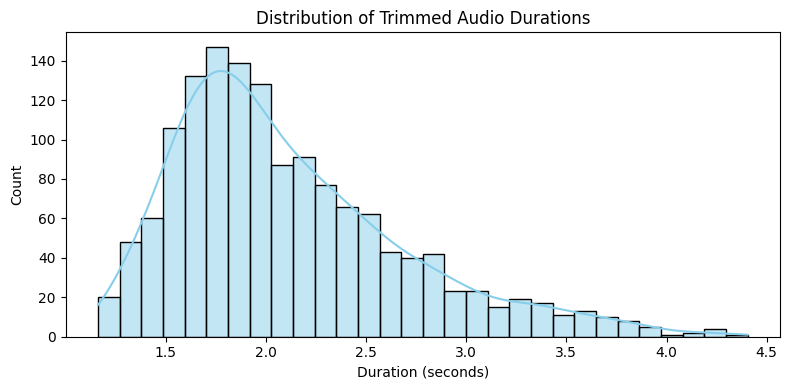

In [11]:
plt.figure(figsize=(8, 4))
sns.histplot(df["trimmed_duration"], bins=30, kde=True, color="skyblue")
plt.title("Distribution of Trimmed Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

/var/folders/lc/kxf912cj7cx90vvvmr9mfwn80000gn/T/ipykernel_1376/1600694022.py:1: FutureWarning: get_duration() keyword argument 'filename' has been renamed to 'path' in version 0.10.0.
	This alias will be removed in version 1.0.
  df["original_duration"] = df["path"].apply(lambda x: librosa.get_duration(filename=x))


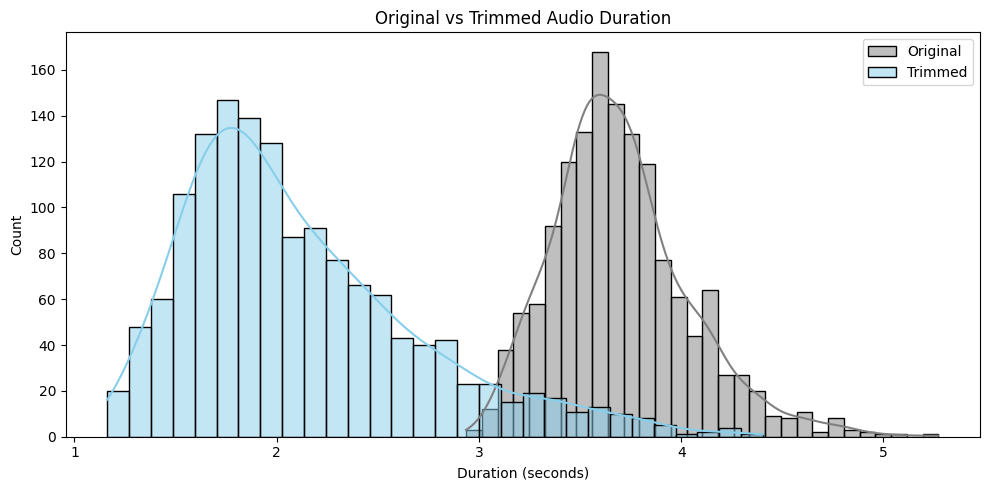

In [12]:
df["original_duration"] = df["path"].apply(lambda x: librosa.get_duration(filename=x))

plt.figure(figsize=(10, 5))
sns.histplot(df["original_duration"], bins=30, label="Original", color="gray", kde=True)
sns.histplot(df["trimmed_duration"], bins=30, label="Trimmed", color="skyblue", kde=True)
plt.legend()
plt.title("Original vs Trimmed Audio Duration")
plt.xlabel("Duration (seconds)")
plt.tight_layout()
plt.show()

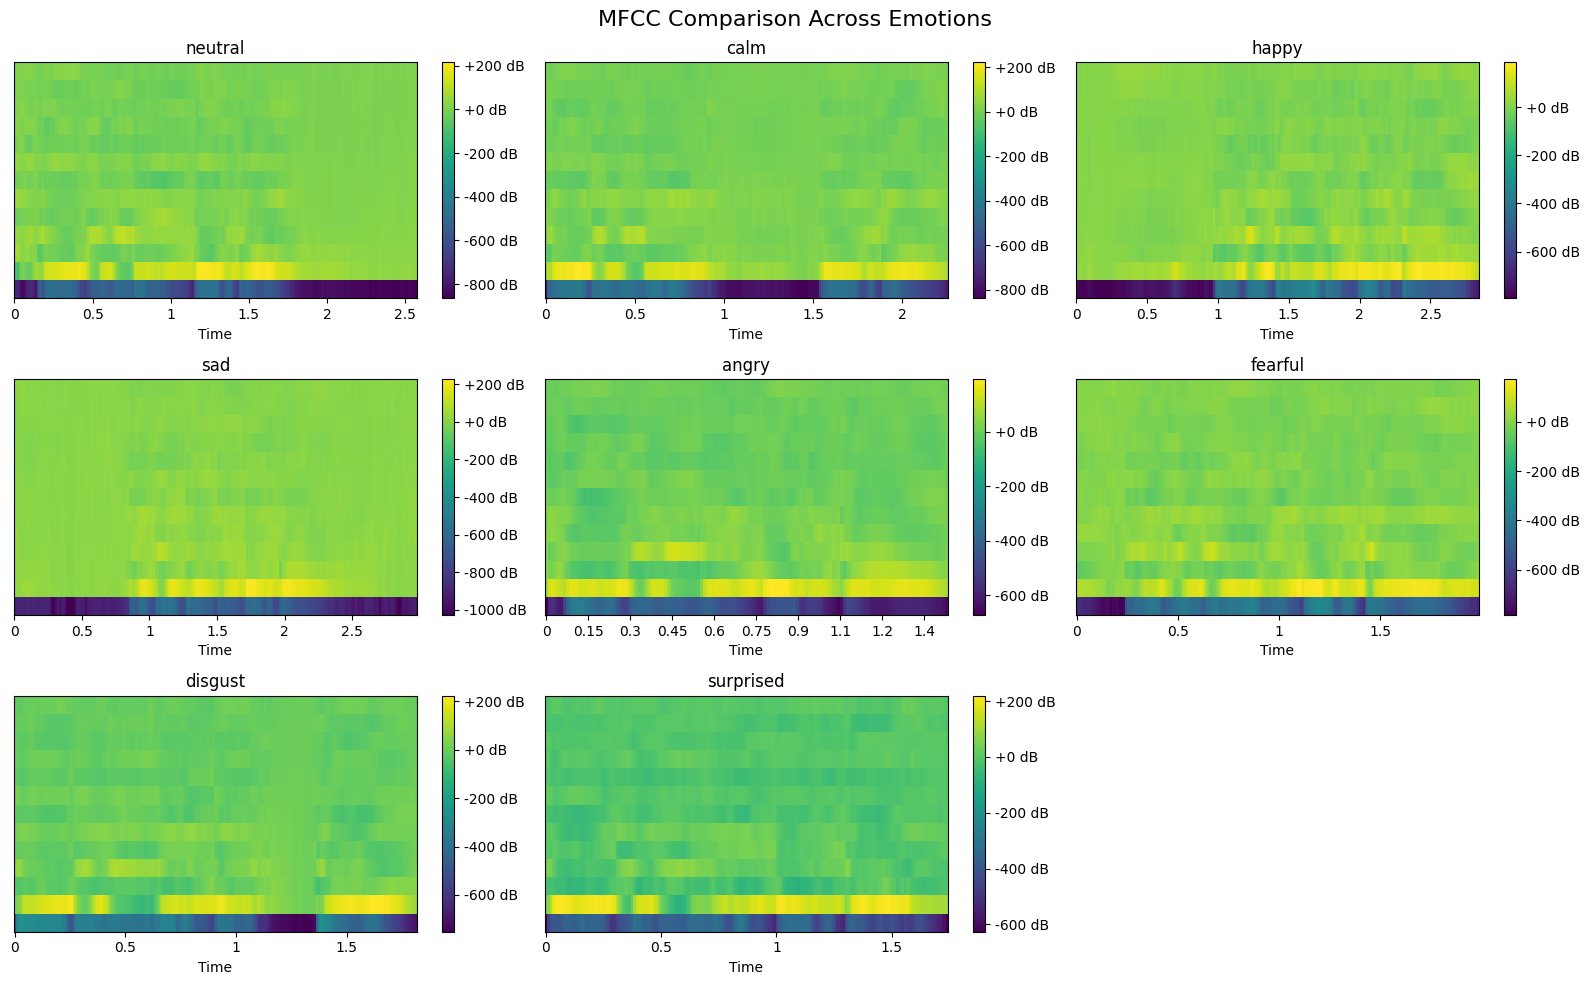

In [13]:
import random

# List of emotions to plot
emotions_to_plot = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

# Set plot style
plt.figure(figsize=(16, 10))
plt.suptitle("MFCC Comparison Across Emotions", fontsize=16)

# Loop through each emotion and plot
for i, emotion in enumerate(emotions_to_plot):
    # Get a random sample for the emotion
    sample_path = df[df["emotion"] == emotion]["path"].sample(1).values[0]

    # Load and trim audio
    y, sr = librosa.load(sample_path, sr=None)
    y_trimmed, _ = librosa.effects.trim(y, top_db=40)

    # Compute MFCCs
    mfcc = librosa.feature.mfcc(y=y_trimmed, sr=sr, n_mfcc=13)

    # Plot
    plt.subplot(3, 3, i + 1)
    librosa.display.specshow(mfcc, sr=sr, x_axis="time", cmap="viridis")
    plt.colorbar(format="%+2.0f dB")
    plt.title(emotion)
    plt.tight_layout()

plt.show()


In [27]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Drop rows with any missing values
df_clean = df.dropna()

# Use actual engineered feature prefixes
feature_cols = [col for col in df_clean.columns if col.startswith(("mfcc_", "delta_", "delta2_", "chroma_", "zcr", "rmse", "trimmed_duration"))]

# Features (X) and Labels (y)
X = df_clean[feature_cols].values
y = df_clean["emotion"].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split into train+val and test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y_encoded, test_size=0.15, stratify=y_encoded, random_state=42
)

# Split train+val into train and validation (70% train, 15% val)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.1765, stratify=y_trainval, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Check class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("Train (scaled):", X_train_scaled.shape, counts)
print("Validation:", X_val_scaled.shape, np.unique(y_val, return_counts=True)[1])
print("Test:", X_test_scaled.shape, np.unique(y_test, return_counts=True)[1])
print("Classes:", label_encoder.classes_)


Train (scaled): (1007, 54) [135 134 134 134 134  68 134 134]
Validation: (217, 54) [29 29 29 29 29 14 29 29]
Test: (216, 54) [28 29 29 29 29 14 29 29]
Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "SVM (RBF Kernel)": SVC(kernel="rbf", C=1, gamma="scale"),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(64,), max_iter=1000, random_state=42),
    "XGBoost": XGBClassifier(
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42,
        n_estimators=150,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.6,
        colsample_bytree=0.6,
        gamma=0
    )
}

results = {}

print("\n📊 Training models...\n")
for name, model in models.items():
    # Use scaled training data (no SMOTE)
    model.fit(X_train_scaled, y_train)

    # Predict on validation set
    val_preds = model.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, val_preds)

    results[name] = {
        "model": model,
        "val_accuracy": val_acc
    }

    print(f"✅ {name} - Validation Accuracy: {val_acc:.4f}")



📊 Training models...

✅ Logistic Regression - Validation Accuracy: 0.4378
✅ Random Forest - Validation Accuracy: 0.5023
✅ Decision Tree - Validation Accuracy: 0.3318
✅ SVM (RBF Kernel) - Validation Accuracy: 0.4839
✅ k-NN (k=5) - Validation Accuracy: 0.3917


/Users/rakanrouchdi/Desktop/VoiceSentiment/VoiceEnv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/rakanrouchdi/Desktop/VoiceSentiment/VoiceEnv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [12:38:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ MLP (Neural Net) - Validation Accuracy: 0.5023
✅ XGBoost - Validation Accuracy: 0.5346



🏆 Best Model: XGBoost

📊 Test Accuracy: 0.5370

📋 Detailed Classification Report (per emotion):
              precision    recall  f1-score   support

       angry       0.77      0.61      0.68        28
        calm       0.51      0.72      0.60        29
     disgust       0.57      0.45      0.50        29
     fearful       0.55      0.55      0.55        29
       happy       0.45      0.52      0.48        29
     neutral       0.50      0.29      0.36        14
         sad       0.48      0.55      0.52        29
   surprised       0.52      0.48      0.50        29

    accuracy                           0.54       216
   macro avg       0.54      0.52      0.52       216
weighted avg       0.55      0.54      0.53       216


✅ Overall Macro F1-score:     0.5244
✅ Overall Weighted F1-score:  0.5349
✅ Macro Precision:            0.5450
✅ Macro Recall:               0.5211
✅ Overall Test Accuracy:      0.5370

🎯 ROC-AUC (OvR):              0.8771
🎯 GINI Score:               

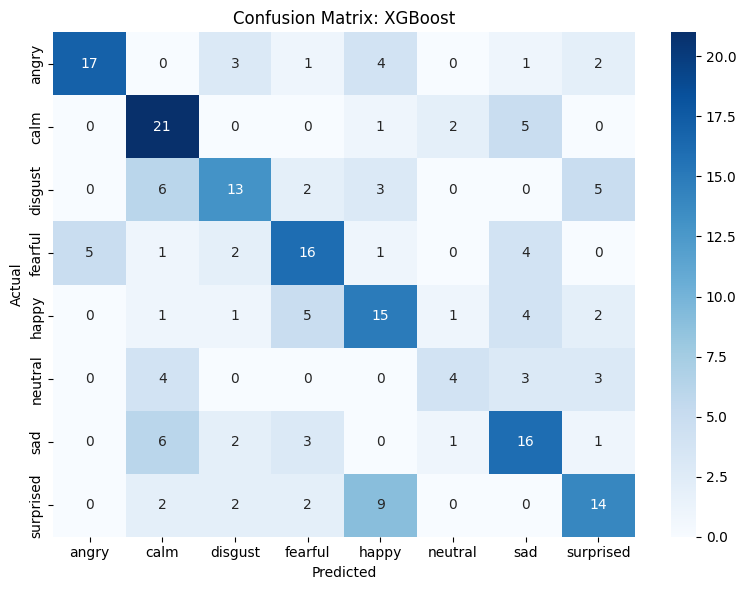

In [35]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# Get best model based on validation accuracy
best_model_name = max(results, key=lambda k: results[k]["val_accuracy"])
best_model = results[best_model_name]["model"]
print(f"\n🏆 Best Model: {best_model_name}")

# Predict on test set
y_test_pred = best_model.predict(X_test_scaled)

# Accuracy
test_acc = accuracy_score(y_test, y_test_pred)
print(f"\n📊 Test Accuracy: {test_acc:.4f}")

# Classification report
report = classification_report(
    y_test, y_test_pred, target_names=label_encoder.classes_, output_dict=True
)
print("\n📋 Detailed Classification Report (per emotion):")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))

# Overall scores
macro_f1 = f1_score(y_test, y_test_pred, average="macro")
weighted_f1 = f1_score(y_test, y_test_pred, average="weighted")
macro_precision = precision_score(y_test, y_test_pred, average="macro")
macro_recall = recall_score(y_test, y_test_pred, average="macro")

# ROC-AUC and GINI
y_test_proba = best_model.predict_proba(X_test_scaled)
roc_auc_ovr = roc_auc_score(y_test, y_test_proba, multi_class="ovr")
gini = 2 * roc_auc_ovr - 1

print(f"\n✅ Overall Macro F1-score:     {macro_f1:.4f}")
print(f"✅ Overall Weighted F1-score:  {weighted_f1:.4f}")
print(f"✅ Macro Precision:            {macro_precision:.4f}")
print(f"✅ Macro Recall:               {macro_recall:.4f}")
print(f"✅ Overall Test Accuracy:      {test_acc:.4f}")
print(f"\n🎯 ROC-AUC (OvR):              {roc_auc_ovr:.4f}")
print(f"🎯 GINI Score:                 {gini:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [42]:
import joblib

# Save model
joblib.dump(best_model, "models/xgboost_emotion_model.pkl")

# Save label encoder and scaler
joblib.dump(label_encoder, "models/label_encoder.pkl")
joblib.dump(scaler, "models/feature_scaler.pkl")


['models/feature_scaler.pkl']